# Imports
We start this document by listing the imports used for the convenience of the reader.

In [65]:
# Imports used within this project
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
from src import LogReg
from src import Tree
from src import Misc

# Tmp: in case I make changes to the helper files, this reloads them
import importlib
importlib.reload(Tree)
importlib.reload(LogReg)
importlib.reload(Misc)

<module 'src.Misc' from 'C:\\Users\\denve\\OneDrive - University of Southampton\\Python projects\\Pitstop\\src\\Misc.py'>

# Formula 1 pitstop predictor

## Explanation of the task
We are [given](https://www.kaggle.com/competitions/playground-series-s6e5) telemetry-style Formula 1 lap data containing the following variables:
1. `Driver`: the driver who performed the lap. A string.
2. `Compound`: the compound of the Tyre the lap was performed with. A string.
3. `Race`: the name of the circuit the lap was performed on. A string.
4. `Year`: the year of the race the lap was performed in. An integer, from `2022`-`2025`.
5. `PitStop`: whether the car pitted this lap. A `0` or a `1`, where `0` means no pit stop occured, and `1` means it did.
6. `LapNumber`: the lap number of the given lap. An integer.
7. `Stint`: the Tyre stint number (stint 1 means: the first set of tyres used in the race, stint 2 means the second set of tyres used for the race, etc). An integer.
8. `TyreLife`: the number of laps the current Tyre stint has been used for. An integer.
9. `Position`: the position the driver was in at the end of the lap.
10. `LapTime (s)`: how long the lap took in seconds. A float.
11. `LapTime_Delta`: presumably, the difference in time compared to the previous lap time. A float.
12. `Cumulative_Degradation`: a measure of cumulated tyre degradation. No concrete definition of this variable could be found. A float.
13. `RaceProgress`: presumably, a number between `0` and `1` representing how much progress has happened for the current race.
14. `Position_Change`: presumably, the change in position based on the previous lap. An integer.
15. `PitNextLap`: whether or not the car pitted the next lap. `0` for false, `1` for true.
16. `Id`: this just seems to index the rows.

We wish to predict the binary variable `PitNextLap` based on the other features. This gives us a supervised binary classification problem.

## Issues with the data
There are some oddities within this dataset that are worth pointing out. The following observations show that the data violates several domain-specific physical constraints that make it overwhelmingly likely to be mostly synthetic. Furthermore, it seems that even lap data for the same driver, within the same race seem to be independent.

### Double pitting
One very easy oddity to spot is that over the whole dataset, the probability the driver pits the next lap given they pitted on the current lap is roughly ${25\%}$:

In [66]:
# Read in the csv
df = pd.read_csv("data/data.csv")
df = df.drop(["id"],axis=1)

# Create a restore point if needed later
df_bak = df.copy()

# Consider only the rows where PitStop == 1
df_pitstop1 = df[df["PitStop"] == 1]
# ... and compute the mean of the PitNextLap column
probs = df_pitstop1["PitNextLap"].mean()
print("Probability of pitting twice in a row: " + str(probs))

Probability of pitting twice in a row: 0.2478293601003764


This is very odd. Only under very special circumstances would a Formula 1 driver pit for multiple laps in a row. We would expect this probability to be much closer to $0$.

### High base pitting rates
The base rates of pitting the current lap and pitting the next lap in the samples are much higher than we would expect if both of the following were true:
1. The samples were drawn without bias.
2. The data generating process faithfully represented real-world dynamics.

In [67]:
print("Sample rate of pitting laps: " + str(df["PitStop"].mean()))
print("Sample rate of laps preceding a pit stop: " + str(df["PitNextLap"].mean()))

Sample rate of pitting laps: 0.13611832217516054
Sample rate of laps preceding a pit stop: 0.19898210137996994


A sample rate of roughly ${14\%}$ of pit stop laps is far higher than what we would expect the true base rate of pitting in Formula 1 to be. Similarly, a sample rate of roughly ${20\%}$ for laps preceding pit stops is also far higher than what we'd expect. It's also worth explicitly noting now that we have class imbalance, which will be important later when it comes to modelling.

### Temporal inconsistencies
Within a given race (which is controlled by the combination of `Race` and `Year`, since each Formula 1 season involves exactly 1 event per circuit), we would expect a driver's stint number to increase monotonically with lap number. For instance, it is physically implausible that the driver is on stint ${3}$ on lap ${30}$, then suddenly on stint ${2}$ on lap ${40}$. However, such reversals do occur with surprising frequency within the dataset:

In [68]:
# Sort the table so that we are looking race by race, driver by driver,
# lap by lap
df = df.sort_values(["Race", "Year", "Driver", "LapNumber"])

# Create a new column recording the stint in the previously
# recorded lap for that driver, in that race
df["prev_Stint"] = df.groupby(["Race", "Year", "Driver"])["Stint"].shift(1)

# ... and record a new column where we check if a stint violation occurred
df["Stint_violation"] = df["Stint"] < df["prev_Stint"]

# And now we can get how often stint violations occur within
# our samples
Stint_violation_rate = df["Stint_violation"].mean()
print("Occurrences of stint violations within this dataset: " + str(Stint_violation_rate))

# Cleanup
df = df.drop(["prev_Stint", "Stint_violation"],axis=1)

Occurrences of stint violations within this dataset: 0.11280684975178759


If all samples were temporally consistent, we would expect this rate to be ${0}$. A small but positive rate could indicate some small sampling errors, and indicate samples that should potentially be rejected. A rate of ${11\%}$ is so high that it seems infeasible to be simple sampling error.

Another oddity loosely related to time is the column `LapTime_Delta`. We would expect the definition of this variable to be simple: the arithmetic difference of the current lap time with the previous. But this doesn't seem to be the case:

In [69]:
# We get two rows corresponding to
# consecutive laps by ALB in the 2023
# Abu Dhabi GP
r1 = df[
    (df["Driver"] == "ALB") &
    (df["Race"] == "Abu Dhabi Grand Prix") &
    (df["Year"] == 2023) &
    (df["LapNumber"] == 56)
]
r2 = df[
    (df["Driver"] == "ALB") &
    (df["Race"] == "Abu Dhabi Grand Prix") &
    (df["Year"] == 2023) &
    (df["LapNumber"] == 57)
]

# We manually compute the laptime delta,
# and also what the supposed laptime delta
# was
LapTime_Delta = r2["LapTime_Delta"].item()
LapTime_Delta_computed = r2["LapTime (s)"].item() - r1["LapTime (s)"].item()
print("LapTime_Delta: " + str(LapTime_Delta))
print("Manually computed lap time delta: " + str(LapTime_Delta_computed))
print("Are they equal? " + str(LapTime_Delta_computed == LapTime_Delta))

LapTime_Delta: -0.0630000000000023
Manually computed lap time delta: -0.10799999999998988
Are they equal? False


The variable `Position_Change` behaves similarly:

In [70]:
# Do the same check as above for Position_Change
Position_Change = r2["Position_Change"].item()
Position_Change_computed = r1["Position"].item() - r2["Position"].item()
print("Position_Change: " + str(Position_Change))
print("Manually computed position delta: " + str(Position_Change_computed))
print("Are they equal? " + str(Position_Change == Position_Change_computed))

Position_Change: 0.0
Manually computed position delta: 2
Are they equal? False


### Drivers in a single race
A Formula 1 race should contain at most ${20}$ drivers, and rarely slightly less when a driver is unable to attend. The variability in the number of drivers in a single race for this dataset is... seemingly much less constrained:

In [71]:
print("Maximum number of drivers in a single race: " + str(df.groupby(["Race", "Year"])["Driver"].nunique().max()))
print("Minimum number of drivers in a single race: " + str(df.groupby(["Race", "Year"])["Driver"].nunique().min()))

Maximum number of drivers in a single race: 856
Minimum number of drivers in a single race: 4


In hindsight, this is also not surprising... the data comprises of many unique drivers with unusual names, and the number of sample laps we have is orders of magnitude above what is physically feasible.

### Important missing features

We note that there are several missing features from the data that are **vital** for pit-stop decision making. These include:
1. Weather-related data.
2. Whether or not that recorded lap occurred during a safety car.
3. More refined positional information, such as the time to the succeeding and preceding drivers.

### Conclusion
We have demonstrated beyond any reasonable doubt that the data:
1. is synthetic in generation, whose data generation process is physically incompatible with real-world domain-specific constraints, and
2. fails to preserve time‑dependent relationships between consecutive laps for the same driver within a race.

## Modelling the data
We now move on to modelling the data. We've proven beyond a reasonable doubt that the data is synthetic; our question now turns to whether or not there is still coherent signal we can uncover, and whether any motorsport-like correlations occur.

### Linear modelling
To begin, we will use a simple logistic regression to model the data. Linear models like logisitic regression are very limited in complexity, but are much easier to interpret than other more complex models. We do, however, run into an issue: `Race`, `Compound`, `Driver`, and even `Year` are categorical features. In order for a model to make use of these features, we need to encode these numerically. Common methods include:

1. Label encoding. This is simply where we give each unique entry its own numerical value. For example, `Monaco Grand Prix` might be encoded as `0`, `Australian Grand Prix` might get encoded as `1`, etc. The problem with this approach is that it injects fake ordinal data, i.e. `Monaco Grand Prix` is less than `Australian Grand Prix`. Certain model types, including linear models like logistic regression, can end up making false inferences from this.
2. One-hot encoding. This is more principled; each categorical column is turned into multiple ${\{0,1\}}$-valued columns, one for each category. For instace, `Race` would turn into `Monaco Grand Prix`, `Australian Grand Prix`, `Abu Dhabi Grand Prix`,.... etc, with `1` in the column that corresponds to which circuit this lap was recorded in, and $0$ elsewhere. With ${N}$ unique categories, we need ${N-1}$ columns (since the ${N^{\text{th}}}$ column can always be deduced from the other ${N-1}$). Hence, with a large cardinality of categories, the dimension of feature space can quickly explode, and samples in feature space can become sparse.
3. Feature engineering techniques, such as feature aggregation. This involves replacing one or more categorical columns with some form of summary statistic based on historial data.

For our attempt at linear modelling, we reject label encoding because of the issues mentioned. As a small sanity check of one-hot encoding + logistic regression, we can compute the EPV. EPV stands for *Events Per Variable*, and is defined by:
$$
\text{Number of events in the minority class} \div \text{Number of features}.
$$
As a very rough heuristic, an EPV of ${10}$ is commonly cited as a threshold associated with stable logistic regression estimates, although this is not a strict requirement.

In [72]:
# Obtain how many unique columns would be required
# to use one-hot encoding with our categorical
# columns
Driver_number = df["Driver"].nunique() - 1
Race_number = df["Race"].nunique() - 1
Compound_number = df["Compound"].nunique() - 1
Year_number = df["Year"].nunique() - 1
onehot_columns = Driver_number + Race_number + Compound_number + Year_number

print("Required number of columns for one-hot encoding: " + str(onehot_columns))

# We can also give a final count of what the dimensionality
# of feature space would be. This can be computed
# by adding the original number of columns, minus 4
# because we removed 4 categorical columns, plus the
# number of one-hot columns produced, minus 1
# for the target variable column.
onehot_final_dimensionality = len(df.columns) - 4 + onehot_columns - 1
print("Final dimensionality of feature space with one-hot encoding: " + str(onehot_final_dimensionality))

# We compute the EPV (events per variable) to sanity check whether
# a logistic regression model is reasonable
events = df["PitNextLap"].value_counts().min()
print("EPV: " + str(events / onehot_final_dimensionality))

Required number of columns for one-hot encoding: 918
Final dimensionality of feature space with one-hot encoding: 928
EPV: 94.16056034482759


#### One-hot encoding + logistic regression

We now do a simple one-hot encoding + logistic regression on the dataset.

For numerical columns, we used a `StandardScaler` to ensure that each feature has comparable scale - without this, features with higher absolute magnitude could dominate gradient updates. This also makes the resulting weights that the model learns roughly comparable.

We also plot the resulting *precision-recall curve*. Our model produces probability estimates when making predictions, and by default, if the model gives a value ${\geq 0.5}$ - it is assigned class `1`. But we can use different thresholds from ${0.5}$. Using a higher threshold means: "only predict class $1$ if you are more confident", increasing precision (probability the prediction is correct given a positive prediction), but decreasing recall (which is defined as the probability of our model predicting class $1$ given a sample from class $1$). A lower threshold means: "we are more comfortable predicting $1$, even when less certain". This increases recall, but lowers precision. This is the classic *precision-recall tradeoff*, which we can plot as a curve.

The user is able to define a target recall-precision balance below, and our code finds the the threshold that gives the closest recall-precision possible with our model (under Euclidean distance).

C:\Users\denve\miniconda3\envs\track\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


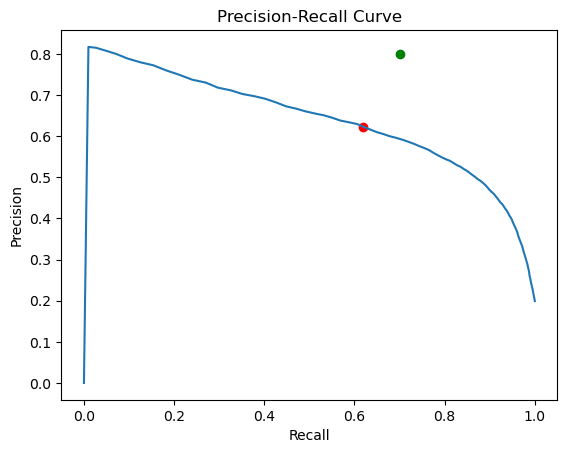

Closest recall-precision attained: (0.6199359121080339, 0.6224648089629417)
Threshold used for that recall-precision: 0.7272727272727273
Accuracy under this threshold: 0.8495582274445507


In [73]:
# We start by splittng the features and target
X = df.drop(columns=["PitNextLap"])
y = df["PitNextLap"]

# We identify the categorical columns, and the
# columns which are already numerical
categorical_cols = ["Race", "Compound", "Year", "Driver"]
numeric_cols = ["LapTime (s)", "LapTime_Delta", "Cumulative_Degradation", "Stint", "TyreLife", "Position", "Position_Change", "RaceProgress", "LapNumber", "PitStop"]

# `target_recallprecision` is the user-defined
# balance of recall-precision we'd like to achieve
target_recallprecision = (0.7,0.8)
clf,recall_list,precision_list,accuracy_list,optimal_threshold,closest_recallprecision,closest_accuracy = LogReg.global_onehot(df,categorical_cols,numeric_cols,target_recallprecision)

# Plot the result
plt.plot(recall_list, precision_list)
plt.scatter(target_recallprecision[0],target_recallprecision[1],color="green", label="Target recall-precision")
plt.scatter(closest_recallprecision[0],closest_recallprecision[1],color="red",label="Closest recall-precision achieved")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

print("Closest recall-precision attained: " + str(closest_recallprecision))
print("Threshold used for that recall-precision: " + str(optimal_threshold))
print("Accuracy under this threshold: " + str(closest_accuracy))

Accuracy is indeed high, but due to class imbalance, high accuracy can be achieved with a "dumb" model (i.e. always predict $0$). Hence, recall and precision, or other related metrics are important to measure model performance on the minority class (`PitNextLap == 1`). A recall and precision of roughly ${60\%}$ is non-trivial!

Let's go ahead and analyse the weights of the numerical features:

In [74]:
# Get the feature names and weights
feature_names = clf.named_steps["preprocessor"].get_feature_names_out()
weights = clf.named_steps["model"].coef_[0]

# Only consider features for the numerical columns
# (not the one-hot encoding columns)
for feature, weight in zip(feature_names, weights):
    if (feature.startswith("num__")):
        print(feature,weight)

num__LapTime (s) -0.057957110861363584
num__LapTime_Delta -0.035942577834240576
num__Cumulative_Degradation -0.17365038654885565
num__Stint 0.798318062032883
num__TyreLife 1.0399753977660184
num__Position 0.03317336214307529
num__Position_Change 0.07933135500570072
num__RaceProgress -1.3884704349948136
num__LapNumber 0.7694821445344701
num__PitStop -0.06115507393373781


Because we normalised our numerical features using `StandardScaler`, feature weights should be roughly comparable. We see that `LapTime (s)`, `LapTime_Delta`, `Position`, `Position_Change`, and `PitStop` have weights that are relatively close to $0$.

`Cumulative_Degradation` has slightly negative weighting, meaning the model has generally associated an increase in this variable with a lower chance of pitting the next lap. This does seem unusual at first glance... we would expect that higher cumulated degradation of tyres would result in a higher pit stop probability. However, as we noted at the start - this variable isn't strictly defined anywhere, and logistic regression is a simplistic model.

`Stint` has a fairly moderate positive weighting, meaning higher `Stint` numbers increase the models predicition of pitting next lap.

`TyreLife` has a highly positive weight, meaning as `TyreLife` increases, the models output probability for pitting next lap also increases. This makes intuitive sense from a motorsport angle, of course - as the tyre within the stint ages, we expect the chance of pitting to increase.

`RaceProgress` and `LapNumber` have weights pointing in different directions. This may seem odd, as we would expect `RaceProgress` and `LapNumber` to both be proxies for race progression. One plausible reason for this is collinearity; we can check this by computing the Pearson correlation coefficient between them:

In [75]:
print("Pearson correlation between `RaceProgress` and `LapNumber`: \n" + str(df[["RaceProgress", "LapNumber"]].corr()))

Pearson correlation between `RaceProgress` and `LapNumber`: 
              RaceProgress  LapNumber
RaceProgress      1.000000   0.964539
LapNumber         0.964539   1.000000


Indeed, they seem to be highly correlated, with a pearson correlation coefficient of ${\approx 0.96}$. Let's retrain the same model with `LapNumber` removed:

In [76]:
df = df.drop(["LapNumber"],axis=1)
X = df.drop(columns=["PitNextLap"])
y = df["PitNextLap"]
numeric_cols = ["LapTime (s)", "LapTime_Delta", "Cumulative_Degradation", "Stint", "TyreLife", "Position", "Position_Change", "RaceProgress", "PitStop"]
target_recallprecision = (0.7,0.8)
clf,recall_list,precision_list,accuracy_list,optimal_threshold,closest_recallprecision,closest_accuracy = LogReg.global_onehot(df,categorical_cols,numeric_cols,target_recallprecision)

print("Closest recall-precision attained: " + str(closest_recallprecision))
print("Threshold used for that recall-precision: " + str(optimal_threshold))
print("Accuracy under this threshold: " + str(closest_accuracy))

# Restore
df = df_bak.copy()

C:\Users\denve\miniconda3\envs\track\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Closest recall-precision attained: (0.6190203707942321, 0.6220458858030016)
Threshold used for that recall-precision: 0.7272727272727273
Accuracy under this threshold: 0.8493532814136722


We indeed get essentially the same performance as the previous model. Let's furthermore analyse the weightings:

In [77]:
feature_names = clf.named_steps["preprocessor"].get_feature_names_out()
weights = clf.named_steps["model"].coef_[0]
for feature, weight in zip(feature_names, weights):
    if (feature.startswith("num__")):
        print(feature,weight)

num__LapTime (s) -0.0630230575479501
num__LapTime_Delta -0.033887042434628624
num__Cumulative_Degradation -0.1764697463338443
num__Stint 0.8399193577184361
num__TyreLife 1.074136686739316
num__Position 0.020031009900524407
num__Position_Change 0.07625042364078866
num__RaceProgress -0.6047304866679787
num__PitStop -0.05378913151338602


After removing `LapNumber`, the weightings of our numerical features have remained largely unchanged, with the exception of `RaceProgress`. This has obtained a moderately negative weighting. This means the model associates earlier race progression as having higher chances of pit stops.

#### Feature aggregation + logisitic regression
We will now train a logistic regression model using feature aggregation, by compressing the categorical features `Race`, `Year`, `Compound` and `Driver` into a summary statistic, namely the mean laptime within the given `Race`, `Year`, `Compound`, and `Driver` grouping. My hypothesis is that most of the signal coming from the categorical features is simply relative performance comparison. Whether a particular `LapTime (s)` is slow or fast is entirely dependent on what track we are on (`Race`), the current generation/performance of car (`Year`, `Driver`), the tyre type (`Compound`), and driving style (`Driver`).

In [78]:
# We compute the aggregate feature
df["Mean_LapTime (s)"] = df.groupby(["Race", "Year", "Compound", "Driver"])["LapTime (s)"].transform("median")

# ... and drop the categorical columns, along with the
# `LapNumber` variable since it was discovered to be
# colinear with `RaceProgress`
df = df.drop(["Race", "Year", "Compound", "Driver", "LapNumber"],axis=1)

X = df.drop(columns=["PitNextLap"])
y = df["PitNextLap"]
numeric_cols = ["Mean_LapTime (s)", "LapTime (s)", "LapTime_Delta", "Cumulative_Degradation", "Stint", "TyreLife", "Position", "Position_Change", "RaceProgress", "PitStop"]
target_recallprecision = (0.7, 0.7)
# We can use the same global_onehot function I wrote, just replacing
# categorical_cols with [] (since there are now no categorical columns
# to one-hot encode)
clf,recall_list,precision_list,accuracy_list,optimal_threshold,closest_recallprecision,closest_accuracy = LogReg.global_onehot(df,[],numeric_cols,target_recallprecision)

print("Closest recall-precision attained: " + str(closest_recallprecision))
print("Threshold used for that recall-precision: " + str(optimal_threshold))
print("Accuracy under this threshold: " + str(closest_accuracy))

# Cleanup
df = df_bak.copy()

Closest recall-precision attained: (0.6192492561226826, 0.44285305070180464)
Threshold used for that recall-precision: 0.5656565656565657
Accuracy under this threshold: 0.7692193833401648


This model performed markedly worse. Recall retained a similar value, but precision is now roughly ${44\%}$, and accuracy has also took a hit down to ${\approx 77\%}$. This suggests the categorical features are likely carrying more signal than simply being a reference for some baseline performance. You can try changing the above code to instead record the median, minimum or maximum lap times within groupings, and the performance hardly changes.

One final thing we'll try is combining the aggregated feature **and** one-hot encoding to see if we get any further performance improvement:

In [79]:
df = df.drop(["LapNumber"],axis=1)
df["Mean_LapTime (s)"] = df.groupby(["Race", "Year", "Compound", "Driver"])["LapTime (s)"].transform("mean")
X = df.drop(columns=["PitNextLap"])
y = df["PitNextLap"]
target_recallprecision = (0.7,0.8)
clf,recall_list,precision_list,accuracy_list,optimal_threshold,closest_recallprecision,closest_accuracy = LogReg.global_onehot(df,categorical_cols,numeric_cols,target_recallprecision)

print("Closest recall-precision attained: " + str(closest_recallprecision))
print("Threshold used for that recall-precision: " + str(optimal_threshold))
print("Accuracy under this threshold: " + str(closest_accuracy))

feature_names = clf.named_steps["preprocessor"].get_feature_names_out()
weights = clf.named_steps["model"].coef_[0]
for feature, weight in zip(feature_names, weights):
    if (feature.startswith("num__")):
        print(feature,weight)

# Restore
df = df_bak.copy()

C:\Users\denve\miniconda3\envs\track\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Closest recall-precision attained: (0.6372739757381551, 0.6207569254779555)
Threshold used for that recall-precision: 0.7171717171717172
Accuracy under this threshold: 0.8503552397868561
num__Mean_LapTime (s) -0.05765329876462959
num__LapTime (s) -0.06499110117411626
num__LapTime_Delta -0.03312406793048849
num__Cumulative_Degradation -0.17175558874680788
num__Stint 0.8439464067485901
num__TyreLife 1.0723629213825552
num__Position 0.014779472127881447
num__Position_Change 0.08319137957959188
num__RaceProgress -0.6009371710546083
num__PitStop -0.05557438613258649


As we can see, the performance is essentially the same as one-hot encoding alone, and the model barely makes use of the `Mean_LapTime (s)` feature for predictions (its weighting is relatively close to 0). The other weights are roughly what they were before.

### Tree-based modelling: XGboost
Our one-hot + logisitic regression model achieved performance above the majority-class baseline, but only marginally (${\approx 60\%}$). We now move onto tree-based modelling. Decision trees, and more generally tree ensembles (like XGBoost and random forests) allow us to naturally capture non-linear, threshold-based feature interactions that linear models don't naturally accomodate.

We train a simple XGBoost model. Unlike in logistic regression, it is much safer to use label encoding in tree-based models. This is because trees learn decision rules through recursive, threshold-based splits rather than by learning linear weighting coefficients.

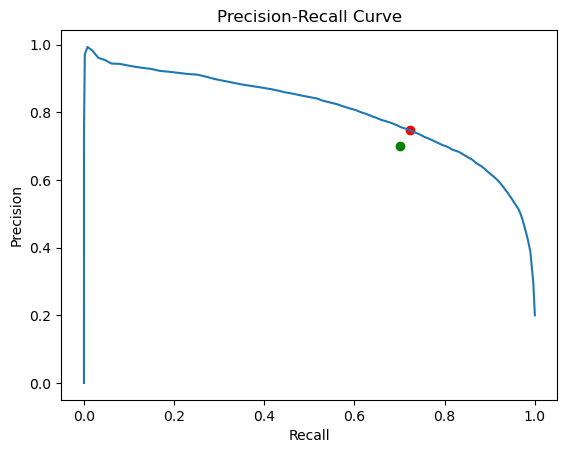

Closest recall-precision attained: (0.7220955421274655, 0.7466548776893605)
Threshold used for that recall-precision: 0.5050505050505051
Accuracy under this threshold: 0.8955572254861776


In [80]:
# Reload base df
df = df_bak.copy()

# Label encode the categorical columns,
# with the exception of `Year` (it's already a numerical value).
categorical_cols = [col for col in categorical_cols if col != "Year"]
df,label_encoders = Tree.label_encode(df,categorical_cols)
# We drop LapNumber, since we discovered that it had
# a high pearson correlation coefficient with RaceProgress
df = df.drop(["LapNumber"],axis=1)
target = ["PitNextLap"]
features = [col for col in list(df.columns) if col != target[0]]
target_recallprecision = (0.7,0.7)
model, recall_list,precision_list, accuracy_list, optimal_threshold, closest_recallprecision, closest_accuracy,X_test,y_test = Tree.xgboost(df,features,target,target_recallprecision)


# Plot the result
plt.plot(recall_list, precision_list)
plt.scatter(target_recallprecision[0],target_recallprecision[1],color="green", label="Target recall-precision")
plt.scatter(closest_recallprecision[0],closest_recallprecision[1],color="red",label="Closest recall-precision achieved")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

print("Closest recall-precision attained: " + str(closest_recallprecision))
print("Threshold used for that recall-precision: " + str(optimal_threshold))
print("Accuracy under this threshold: " + str(closest_accuracy))

# Restore
df = df_bak.copy()

We get quite the jump in performance: just over ${10\%}$ increases in both recall **and** precision.

#### XGboost shap analysis
Unlike linear models like logistic regression, there aren't any simple weights the model learns that we can analyse. However, we can attempt to analyse the model through shap values. At a high level, for a given sample of the data, shap values tell us how much each feature contributed to the final output. In our context, a more positive shap value of a feature for a given sample indicates "this feature nudged the model towards predicting a pit stop for this sample". A shap value close to $0$ for a given sample means, "this particular feature didn't contribute much towards the models prediction". A more negative shap value means "this particular feature nudged our model towards predicting that a pit stop wouldn't occur".

We start by plotting the mean absolute shap value for each feature across a set of samples. Shap values measure how much a feature contributes to moving a prediction away from the model's baseline prediction. If the model relies heavily on a particular feature, that feature will tend to have larger-magnitude shap values across many samples, leading to a higher mean absolute shap value and a higher ranking in the plot.

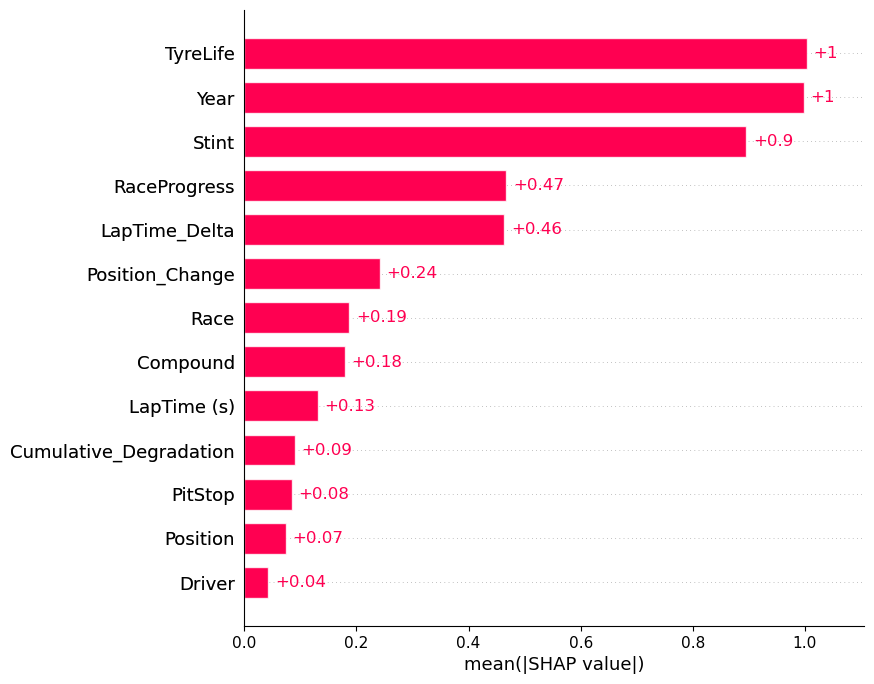

In [81]:
explainer = shap.Explainer(model)
# We sample 1500 samples from the test set.
# Computing shap values can get computationally
# expensive fast, so we restrict to, at-most,
# a couple-thousand sample rows at a time.
X_sample = X_test.sample(1500, random_state=42)
shap_values = explainer(X_sample)
# Feature importance metric (mean absolute shap)
shap.plots.bar(shap_values,max_display=20)

Across the samples we provided, `TyreLife` is the one with highest mean absolute shap. In the context of motorsport, this makes intuitive sense: the age of the tyre is a hard limiting factor when it comes to pitstop decisions.

It is somewhat surprising that `Year`, `Stint`, and `RaceProgress` have higher mean absolute shap than `LapTime_Delta` across our samples. We'd expect `LapTime_Delta`, being a direct measure of real-time performance improvement / degradation, to exhibit higher relative importance. You can change the `random_state` variable in the code above to any integer you like to change the samples considered, and note that this is actually stable across samples from `X_test`. It suggests these variables contain information that the model has learned to exploit, either directly, or through interactions with other features.

`Position_Change` being closer to the top in ranking rather than the bottom would make sense in a motorsport context. One could imagine the relative change in position between laps as being relevant for pitting in terms of strategic calls (undercutting and overcutting).

On the surface, `PitStop` seems lower in the above ranking than we'd expect; however, care needs to be taken when interpreting global mean absolute shap values. A feature can be conditionally important in a very small regime of the data, but when averaged more globally, can appear less important. We can check this directly by replotting the mean abs shap chart, considering only samples when `PitStop == 1`:

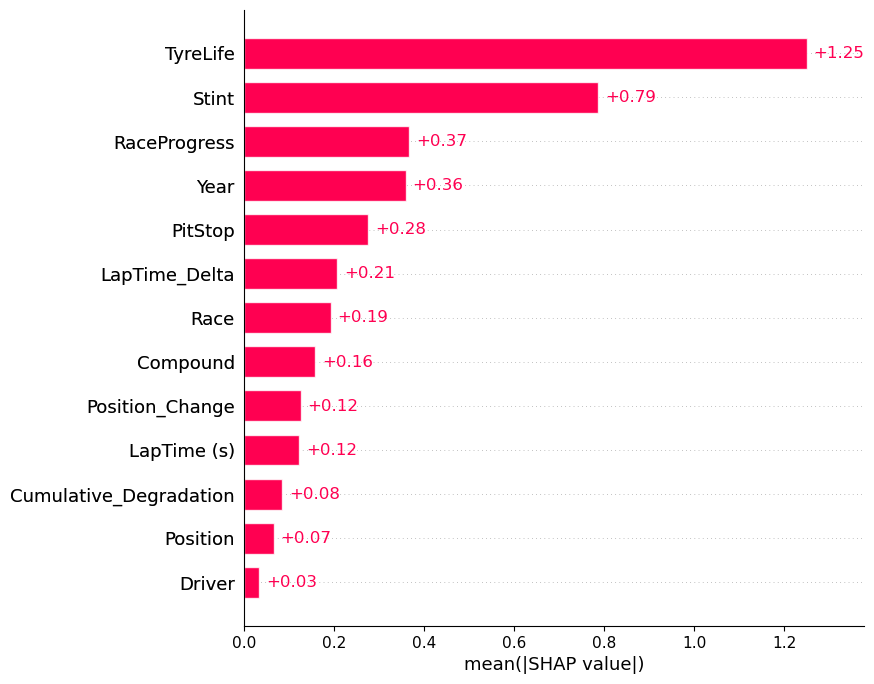

In [82]:
X_sample = (X_test[X_test["PitStop"] == 1]).sample(1500, random_state=42)
shap_values = explainer(X_sample)
shap.plots.bar(shap_values,max_display=20)

As we can see, `PitStop` has now jumped much higher in the ranking of mean absolute shap values. This suggests that, while its global importance appears relatively low, it is conditionally more influential within the subset of `X_test` where `PitStop==1`.

We'll now do a *Beeswarm* plot for our shap values:

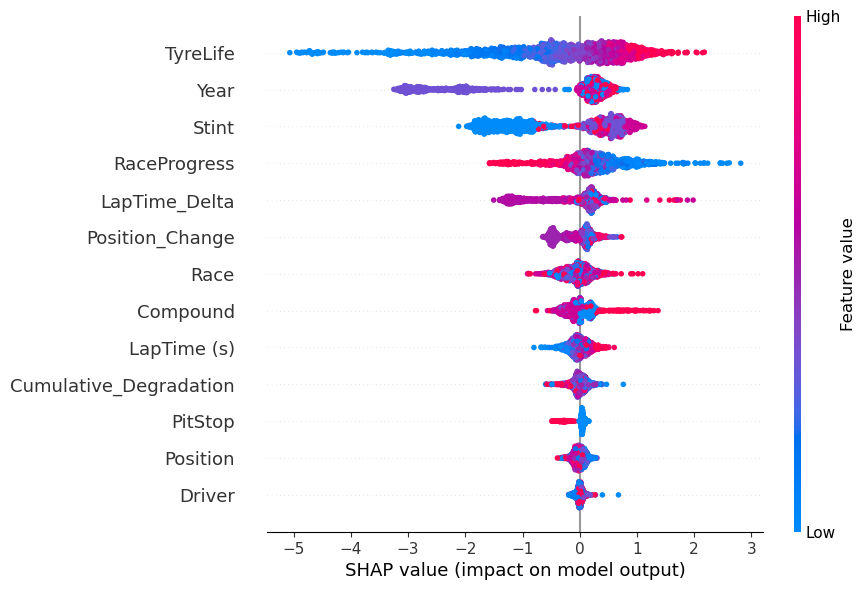

In [83]:
X_sample = X_test.sample(1500, random_state=42)
shap_values = explainer(X_sample)
shap.plots.beeswarm(shap_values,max_display=20)

Each point in the plot corresponds to a single sample. For a given feature, points are colour-coded according to the value of that feature (red = higher values, blue = lower values, purple = intermediate values), while the horizontal position of the point indicates the corresponding shap value.

For `TyreLife`, we observe that larger feature values tend to be associated with more positive shap values. This suggests that, across our samples, older tyres generally increase the model's predicted probability of a pit stop. A similar pattern can be seen for `Stint`, where higher stint numbers tend to increase the model's pit-stop prediction. The model also associates lower values of `RaceProgress` with higher pit-stop probabilities, suggesting that the model has learned a tendency to predict pit stops more frequently earlier in a race. For these features, the XGBoost model broadly agrees with the trends identified by our earlier linear model.

One notable difference is the behaviour of `PitStop`. Across the samples, `PitStop == 1` tends to decrease the models prediction for pit stops. This makes sense from a motorsport angle: if you pit the current lap, it's less likely you'll pit the following lap.

Similarly, higher values of `LapTime (s)` tend to produce more positive shap values, indicating that slower lap times increases the model predicted likelihood of pitting next lap. This is intuitively plausible: slower lap times could indicate higher tyre wear.

`Year` is particularly interesting. Unlike the label-encoded categorical variables (`Race`, `Compound`, and `Driver`), whose encoded values have no meaningful numerical ordering, `Year` possesses a natural ordinal structure. The beeswarm plot shows that observations from certain years tend to have negative shap values, suggesting that the model has associated those seasons with a lower probability of pit stops. From a motorsport angle, this could make sense, as it may reflect season-specific effects such as changes in regulations, tyre compounds, race formats, or strategic trends.

Another thing I'd like to point out is `Position_Change`. We see mostly purple on the negative side of the shap-axis. In other words, intermediate values of `Position_Change` (which we'd expect to be roughly $0$ across the samples) lower the models output probability for pitting next lap. In motorsport terms, one plausible explanation is that maintaining position could decrease the need for strategic pit stop decisions.

#### XGBoost error analysis
We now have a model with decent performance. To finish off our discussion, we'll do some simple, first-order analysis of the failures of our XGBoost model. Let's first get the failure cases within the test split `X_test`, and order the errors:

In [84]:
# First, re-join the dataframe so we have
# the true class values
df_eval = X_test.copy()
df_eval["class"] = y_test.values
# Put our probabilities alongside
df_eval["model_assigned_probability"] = model.predict_proba(X_test)[:, 1]
# ... and our predictions
df_eval["prediction"] = (df_eval["model_assigned_probability"] >= optimal_threshold).astype(int)
# Leave only the rows that are misclassified
df_eval = df_eval[~ (df_eval["class"] == df_eval["prediction"])]
# Compute the absolute error for each row
# (that is, |our probability - target|)
df_eval["abs_error"] = np.abs(df_eval["class"] - df_eval["model_assigned_probability"])
# ... and sort it so that the top rows are the worst
# samples (highest absolute error)
df_eval = df_eval.sort_values("abs_error", ascending=False)

print("Number of misclassified rows within X_test: " + str(len(df_eval)))

Number of misclassified rows within X_test: 9173


Let's manually inspect the top 10 worst failures:

In [85]:
# Before taking a look,
# we convert back the label encoded features
# to make it readable
readable = df_eval.copy()
readable["Race"] = label_encoders[0].inverse_transform(readable["Race"])
readable["Compound"] = label_encoders[1].inverse_transform(readable["Compound"])
readable["Driver"] = label_encoders[2].inverse_transform(readable["Driver"])
# Now let's take a look
print(readable.head(10))

       Driver      Compound                      Race  Year  PitStop  Stint  \
380297   D287          SOFT        Bahrain Grand Prix  2023        0      4   
63601     KOV        MEDIUM      Singapore Grand Prix  2023        0      1   
356365   D287          HARD      Las Vegas Grand Prix  2023        0      1   
397126    GLO        MEDIUM        British Grand Prix  2023        0      1   
346530   D041  INTERMEDIATE         Monaco Grand Prix  2023        0      4   
101063   D157        MEDIUM     Australian Grand Prix  2022        1      1   
44564    D096          HARD     Azerbaijan Grand Prix  2023        0      2   
195639    YAM          HARD  United States Grand Prix  2023        0      3   
211644   D270        MEDIUM        Pre-Season Testing  2023        0      1   
168724   D235          SOFT       Japanese Grand Prix  2023        0      1   

        TyreLife  Position  LapTime (s)  LapTime_Delta  \
380297      11.0        15       98.634          0.030   
63601        1

There isn't any easily identifiable, human readable common thread between these errors. We can, however, note:
1. The above samples are all from class $1$.
2. `Compound == "MEDIUM"` shows up disproportionally to the other compounds.
3. $4$ of the samples have `TyreLife == 1`. We wouldn't expect a Formula 1 driver to pit after only using the tyres for $1$ lap, unless there are other factors at play, such as: weather changes, mechanical failures, potentially a red flag from a driving incident. These variables are not directly available to us as features, and since the given the data is synthetic and violates many domain-specific constraints - it seems unlikely these scenarios would have been accuractely modelled.
4. Most of the `LapTime_Delta` values are around $0$ or are negative, meaning that the cars performance was not worse than the previous lap. Furthermore, the `Position_Change` is relatively small (mostly ${0}$, meaning the position didn't change).

Without further context, these pit decisions are genuinely very difficult to justify from a motorsport lens.

We have to be careful with the observations above, as there is a subtlety: the failures are taken as a subset of `X_test`. If, for example, class $1$ were already disproportionally sampled in `X_test`, then the fact they show up more frequently as failures isn't necessarily deviation from the expected baseline. For example, if ${80\%}$ of the samples in `X_test` were from class $1$, then we would expect, on average, for any randomly chosen subset to also have a roughly ${80\%}$ class $1$ prevelence.

We will attempt to analyse whether failures across the test split are uniformly distributed, or concentrate within certain regimes. In order to measure deviation from that null uniform baseline, we can use *lift* (also referred to as *enrichment*), which is defined as:
$$
\text{Lift}_{\text{class 1}}(\text{a subset }\mathcal{S}\text{ of X\_test}) = \frac{P(\text{class 1}\ |\ \text{in subset }\mathcal{S})}{P(\text{class 1}\ |\ \text{in X\_test})}.
$$
Lift has the following interpretation:
1. ${\text{Lift}_{\text{class 1}}(\mathcal{S}) < 1}$: if the lift is less than $1$, that means that the occurence rate of class $1$ within ${\mathcal{S}}$ is lower than the baseline rate established by `X_test`.
2. ${\text{Lift}_{\text{class 1}}(\mathcal{S}) \approx 1}$: if the lift is "close enough" to $1$, that means the occurence rate of class $1$ within ${\mathcal{S}}$ is roughly the same as `X_test`. Of course, even random sampling won't give the same exact rate of occurence, and so "close enough to $1$" here is dependent on the size of both ${\mathcal{S}}$ and `X_test`.
3. ${\text{Lift}_{\text{class 1}}(\mathcal{S}) > 1}$: if the lift is greater than $1$, that means that the occurence rate of class $1$ within ${\mathcal{S}}$ is higher than the baseline rate established by `X_test`.


We will compute the lift with ${\mathcal{S} = \{\text{failure samples in X\_test}\}}$:

In [86]:
# Let's first compute the prevalence rate of class 1 in X_test
X_test_stitched = X_test.copy()
X_test_stitched["class"] = y_test.values
# Now we compute the lift:
lift_class1 = Misc.lift(df_eval,X_test_stitched,["class"],1)
print("The lift associated with class 1 when considering model failures in X_test: " + str(lift_class1))

The lift associated with class 1 when considering model failures in X_test: 2.660829905813688


A lift value of ${\approx 2.5}$ indicates that class 1 is overrepresented among the failure cases in `X_test`. Specifically, class 1 appears ${\approx 2.5}$ times more frequently in the failure subset than in the overall test set.

We can also compute lift for other properties in a similar way by replacing the target event in the definition (e.g. class 1) with another binary event of interest. For example, we can compute lift by `Compound`:

In [87]:
# Range through the compounds
# We will record the compounds and their lifts
# for a plot
compound_list = []
compound_lift_list = []
for compound_code in range(0,5):
    # Get the human readable compound type
    compound = label_encoders[1].inverse_transform([compound_code])[0]
    # Now, compute the lift
    compound_lift = Misc.lift(df_eval,X_test,["Compound"],compound_code)
    print("Lift associated to `Compound==" + str(compound) + "` for the failure set within X_test: " + str(compound_lift))
    # Record for the plot
    compound_list.append(compound)
    compound_lift_list.append(compound_lift)

Lift associated to `Compound==HARD` for the failure set within X_test: 1.4757075739954535
Lift associated to `Compound==INTERMEDIATE` for the failure set within X_test: 0.9932293800772132
Lift associated to `Compound==MEDIUM` for the failure set within X_test: 0.5869482148929561
Lift associated to `Compound==SOFT` for the failure set within X_test: 1.169514152349512
Lift associated to `Compound==WET` for the failure set within X_test: 0.37749402465627857


A lift of ${\approx 0.6}$ for `Compound==MEDIUM` indicates that this compound is under-represented among the failure cases in `X_test`. Similarly, `Compound==WET` is also under-represented. `Compound==INTERMEDIATE` has a lift close to $1$, indicating a prevalence that is essentially the same as the baseline rate in `X_test`. `Compound==HARD` is slightly over-represented, while for `Compound==SOFT` lift is close enough to $1$ that it's difficult to draw conclusions. To mitigate this, we compute a ${99\%}$ empirical null interval. That is: we repeatedly sample subsets from `X_test` with the same size as our failure set, and compute the corresponding lift values, then observe where the central ${99\%}$ of the resulting lift values lie.

Estimated central 99% lift null interval for `Compound==HARD`: (0.97, 1.03)
Estimated central 99% lift null interval for `Compound==INTERMEDIATE`: (0.87, 1.12)
Estimated central 99% lift null interval for `Compound==MEDIUM`: (0.97, 1.03)
Estimated central 99% lift null interval for `Compound==SOFT`: (0.92, 1.08)
Estimated central 99% lift null interval for `Compound==WET`: (0.62, 1.51)


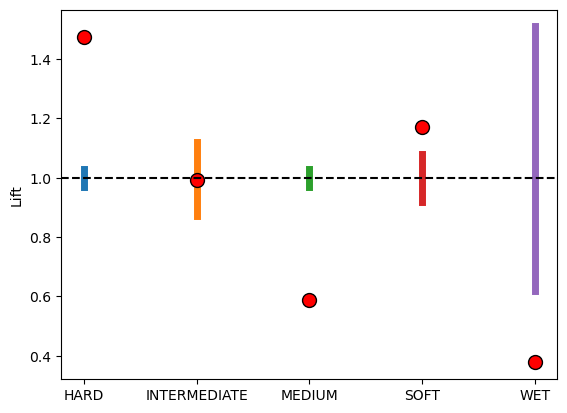

In [88]:
# Record the upper and lower bounds for the plot
compound_99_upper_list = []
compound_99_lower_list = []
for compound_code in range(0,5):
    compound = label_encoders[1].inverse_transform([compound_code])[0]
    # Get the 99% null interval
    NI = Misc.empirical_lift_NI(X_test,len(df_eval),["Compound"],compound_code,experiments=2000, dp=2)
    print("Estimated central 99% lift null interval for `Compound==" + str(compound) + "`: " + str(NI))
    compound_99_lower_list.append(NI[0])
    compound_99_upper_list.append(NI[1])

# Now we plot it
Misc.lift_plot(compound_list, compound_99_lower_list, compound_99_upper_list, compound_lift_list)

We are using Monte Carlo simulation for estimating the ${99\%}$ empirical null intervals of our lift values, and as such, re-running the above code will produce slightly different estimates. However, after running the code a few times, the bounds are stable enough for the qualitative comparisons we wish to make:
1. `Compound == HARD` having a lift of ${\approx 1.5}$ is well above what is expected under the null distribution.
2. `Compound == INTERMEDIATE` having a lift of ${\approx 1}$ is within what is expected under the null distribution.
3. `Compound == MEDIUM` having a lift of ${\approx 0.6}$ is lower than what is expected under the null distribution.
4. `Compound == SOFT` having a lift of ${\approx 1.17}$ is slightly above what is expected under the null distribution.
5. `Compound == WET` having a lift of ${\approx 0.38}$ is lower than what is expected under the null distribution.

It should be noted that the lift of compounds are of course not independent: an increase of lift in one category necessarily means a decrease in the lift of one or more other categories. In fact: lift for different features cannot be considered independent.

We also compute the same null interval for class $1$ lift for completeness. As expected, the observed value lies well above the ${99\%}$ null interval:

In [89]:
NI = Misc.empirical_lift_NI(X_test_stitched, len(df_eval), ["class"], 1, experiments=2000, dp=2)
print("99% null interval for class 1: " + str(NI))

99% null interval for class 1: (0.95, 1.05)


We'll do the same style of plot above for the feature `Year`, since it also contains a small number of categories (of which there are 4), allowing the confidence intervals to be computed in a reasonable timeframe:

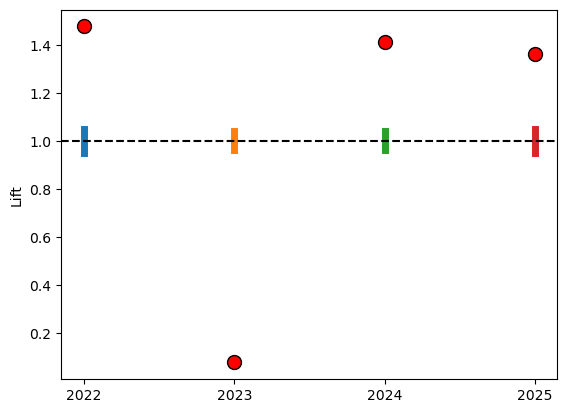

In [90]:
Year_list = []
Year_lift_list = []
Year_99_lower_list = []
Year_99_upper_list = []
for year in range(2022,2026):
    Year_list.append(str(year))
    Year_lift_list.append(Misc.lift(df_eval,X_test,["Year"],year))
    NI = Misc.empirical_lift_NI(X_test, len(df_eval), ["Year"], year, experiments=2000, dp=2)
    Year_99_lower_list.append(NI[0])
    Year_99_upper_list.append(NI[1])
Misc.lift_plot(Year_list,Year_99_lower_list,Year_99_upper_list,Year_lift_list)

We observe that `Year == 2023` is strongly under-represented among the failure cases, with a lift close to $0$ relative to the test set baseline. The other years exhibit similar enrichment levels of ${\approx 1.4}$.

Based on our earlier observation of the worst failures within our test sample, we'll finish our error analysis by:
1. computing the lift for `TyreLife == 1` and the ${99\%}$ empirical null interval for it,
2. computing the lift for the binary condition `LapTime_Delta <= 0` and the ${99\%}$ empirical null interval for it.

In [91]:
TyreLife1_lift = Misc.lift(df_eval,X_test,["TyreLife"],1)
TyreLife1_NI = Misc.empirical_lift_NI(X_test, len(df_eval), ["TyreLife"], 1, experiments=2000, dp=2)

print("TyreLife==1 lift: " + str(TyreLife1_lift))
print("TyreLife==1 99% null interval: " + str(TyreLife1_NI))

# We create a new column for the outcomes of the binary condition
# LapTime_Delta<=0
df_eval["LapTime_Delta0"] = (df_eval["LapTime_Delta"] <= 0).astype(int)
X_test["LapTime_Delta0"] = (X_test["LapTime_Delta"] <= 0).astype(int)

LapTime_Delta_lift = Misc.lift(df_eval,X_test,["LapTime_Delta0"],1)
LapTime_Delta_NI = Misc.empirical_lift_NI(X_test, len(df_eval), ["LapTime_Delta0"], 1, experiments=2000, dp=2)

print("LapTime_Delta<=0 lift: " + str(LapTime_Delta_lift))
print("LapTime_Delta<=0 99% null interval: " + str(LapTime_Delta_NI))

TyreLife==1 lift: 0.04920687104293242
TyreLife==1 99% null interval: (0.88, 1.12)
LapTime_Delta<=0 lift: 1.0407162898241253
LapTime_Delta<=0 99% null interval: (0.98, 1.02)


We observe that `TyreLife == 1` is significantly under-represented among failure cases, with a lift well below the lower bound of the ${99\%}$ empirical null interval. In contrast, `LapTime_Delta <= 0` lies within the expected null range.

**To conclude our error analysis**:
1. Expected hard cases: we manually inspected some of the worst failures within the test split. These errors do not share a single obvious cause and many pit decisions appear genuinely difficult to justify from the available features.
2. Class enrichment: class $1$ is enriched among failures relative to the test set baseline. The failure segment shows a class 1 lift of ${\approx 2.5}$, meaning that the class $1$ rate in the segment is ${\approx 2.5}$ times that of the class $1$ rate in the test set.
3. Compound enrichment: an initial inspection of the top ${10}$ worst failures suggested `Compound == "MEDIUM"` might be over-represented among failures. After computing per-compound lifts with ${99\% }$ empirical null intervals, that hypothesis is not supported. `Compound == "MEDIUM"` is under-represented among failures, while `Compound == "HARD"` is the most enriched.
4. Year enrichment: we found that `Year==2023` is clearly under-represented within failures, while the other `Year`s are over-represented with enrichments of ${\approx 1.4}$.
5. Tyre life enrichment: the initial inspection suggested that `TyreLife==1` might be over-represented among failures. After computing the lift, we noted that `TyreLife==1` was clearly under-represented among failures.
6. Lap time delta enrichment: the initial inspection suggested that `LapTime_Delta<=0` might be over-represented among failures. We noted that `LapTime_Delta<=0` had a lift close to $1$ and was within expected limits of the null distribution. 

**Interpretation and limitations**

Computing the lift associated to a given category for failures within a given sample set can help us understand where failure modes within the test set tend to concentrate; however, they do not support global statements about model behaviour (e.g. "the model consistently struggles with category $X$"), or give any single causal explanation for why they concentrate in this way. Changing the train-test split will generally yield totally different lift values. Furthermore, potential correlations between features make interpreting them potentially misleading. Instead, lift provides a marginal view of how feature distributions shift within the failure subset.

# Conclusion

We worked with a synthetically generated, telemetry‑style F1 dataset to predict whether a car would pit on the following lap. Early inspection revealed several violations of domain‑specific constraints, indicating that the data lacked full physical fidelity. Furthermore, key domain signals such as weather and safety‑car periods were not present.

A baseline logistic regression model was trained under two feature‑engineering strategies. One‑hot encoding achieved balanced performance (${\approx 60\%}$ recall and ${\approx 60\%}$ precision), whereas compressing categorical columns into summary statistics performed markedly worse: recall remained ${\approx 60\%}$, but precision dropped to ${\approx 44\%}$.

Switching to a tree-based ensemble (XGBoost) with label‑encoded categorical features produced a substantial improvement, with both recall and precision increasing significantly (${\approx 72\%}$ and ${\approx 75\%}$ respectively). This suggests that the dataset contains non‑linear structure that tree‑based methods can exploit. Shap analysis showed that while some feature effects aligned with the linear model, others revealed novel interactions invisible to initial linear methods.

Finally, a first‑order error analysis using lift demonstrated that model failures were not uniformly distributed across the test set. Lift values consistently fell outside empirically computed ${99\%}$ null intervals, indicating that errors concentrate in specific feature regimes within the test split.

# Next steps

We list here some potential next steps for further investigating this dataset:
1. **Error slicing**: use the enriched failure regimes identified by the lift analysis to guide targeted error slicing. For example, since we know `Compound==HARD` is the most over-represented compound in failures from our test set, we could study those samples and ask further questions.
2. **Conditional shap analysis**: we could condition on certain feature regimes and ask if shap values behave differently across those them.
3. **Partial dependent plots**: we could produce partial dependence plots. This shows the average effect of one (or potentially more) features on a model's prediction, with all other features averaged out.
4. **Further feature engineering**: even though the dataset is synthetic and not faithful to F1 dynamics, we could engineer domain-informed features and see if we gain any performance. For example, even though safety car-type information is missing from the data, we could attempt to infer such data by relative performance anomalies.